In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [17]:
dataset = load_diabetes(as_frame=True)

df = dataset.frame

print(df)

          age       sex       bmi  ...        s5        s6  target
0    0.038076  0.050680  0.061696  ...  0.019907 -0.017646   151.0
1   -0.001882 -0.044642 -0.051474  ... -0.068332 -0.092204    75.0
2    0.085299  0.050680  0.044451  ...  0.002861 -0.025930   141.0
3   -0.089063 -0.044642 -0.011595  ...  0.022688 -0.009362   206.0
4    0.005383 -0.044642 -0.036385  ... -0.031988 -0.046641   135.0
..        ...       ...       ...  ...       ...       ...     ...
437  0.041708  0.050680  0.019662  ...  0.031193  0.007207   178.0
438 -0.005515  0.050680 -0.015906  ... -0.018114  0.044485   104.0
439  0.041708  0.050680 -0.015906  ... -0.046883  0.015491   132.0
440 -0.045472 -0.044642  0.039062  ...  0.044529 -0.025930   220.0
441 -0.045472 -0.044642 -0.073030  ... -0.004222  0.003064    57.0

[442 rows x 11 columns]


In [21]:
print(df.head())
print()
print(df.tail())

        age       sex       bmi        bp  ...        s4        s5        s6  target
0  0.038076  0.050680  0.061696  0.021872  ... -0.002592  0.019907 -0.017646   151.0
1 -0.001882 -0.044642 -0.051474 -0.026328  ... -0.039493 -0.068332 -0.092204    75.0
2  0.085299  0.050680  0.044451 -0.005670  ... -0.002592  0.002861 -0.025930   141.0
3 -0.089063 -0.044642 -0.011595 -0.036656  ...  0.034309  0.022688 -0.009362   206.0
4  0.005383 -0.044642 -0.036385  0.021872  ... -0.002592 -0.031988 -0.046641   135.0

[5 rows x 11 columns]

          age       sex       bmi  ...        s5        s6  target
437  0.041708  0.050680  0.019662  ...  0.031193  0.007207   178.0
438 -0.005515  0.050680 -0.015906  ... -0.018114  0.044485   104.0
439  0.041708  0.050680 -0.015906  ... -0.046883  0.015491   132.0
440 -0.045472 -0.044642  0.039062  ...  0.044529 -0.025930   220.0
441 -0.045472 -0.044642 -0.073030  ... -0.004222  0.003064    57.0

[5 rows x 11 columns]


In [22]:
df.shape

(442, 11)

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [24]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [25]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

C:\Users\ADARSH S SAHOO\AppData\Local\Temp\ipykernel_9020\842563093.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, ax=axes[0], palette="coolwarm")


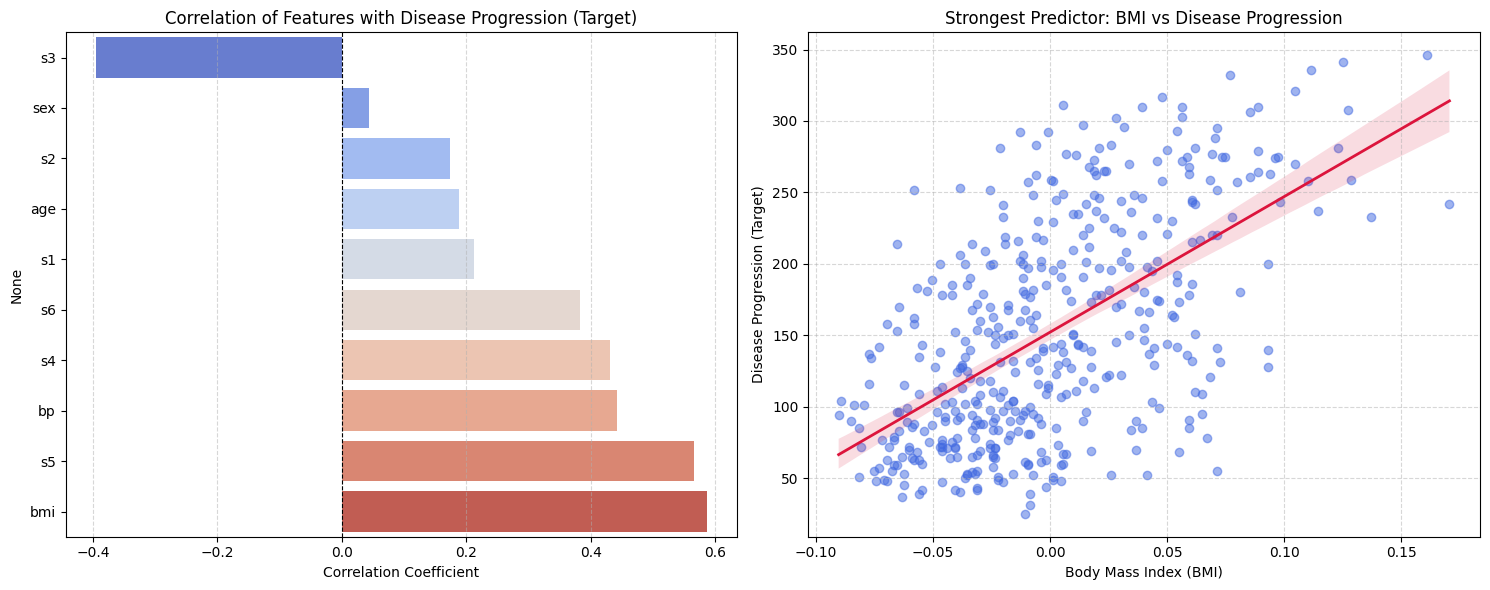

In [26]:
correlations = df.corr()['target'].drop('target').sort_values()

# 3. Create a side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Left: Bar chart of feature correlations with the target
sns.barplot(x=correlations.values, y=correlations.index, ax=axes[0], palette="coolwarm")
axes[0].set_title("Correlation of Features with Disease Progression (Target)")
axes[0].set_xlabel("Correlation Coefficient")
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# Plot Right: Scatter plot & Regression line for the strongest predictor (BMI)
sns.regplot(
    data=df, 
    x='bmi', 
    y='target', 
    ax=axes[1], 
    scatter_kws={'alpha':0.5, 'color': 'royalblue'}, 
    line_kws={'color': 'crimson', 'linewidth': 2}
)
axes[1].set_title("Strongest Predictor: BMI vs Disease Progression")
axes[1].set_xlabel("Body Mass Index (BMI)")
axes[1].set_ylabel("Disease Progression (Target)")
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [29]:
X = df.drop(columns="target")
y = df["target"]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [52]:
y_pred = model.predict(X_test)

y_pred

array([139.5475584 , 179.51720835, 134.03875572, 291.41702925,
       123.78965872,  92.1723465 , 258.23238899, 181.33732057,
        90.22411311, 108.63375858,  94.13865744, 168.43486358,
        53.5047888 , 206.63081659, 100.12925869, 130.66657085,
       219.53071499, 250.7803234 , 196.3688346 , 218.57511815,
       207.35050182,  88.48340941,  70.43285917, 188.95914235,
       154.8868162 , 159.36170122, 188.31263363, 180.39094033,
        47.99046561, 108.97453871, 174.77897633,  86.36406656,
       132.95761215, 184.53819483, 173.83220911, 190.35858492,
       124.4156176 , 119.65110656, 147.95168682,  59.05405241,
        71.62331856, 107.68284704, 165.45365458, 155.00975931,
       171.04799096,  61.45761356,  71.66672581, 114.96732206,
        51.57975523, 167.57599528, 152.52291955,  62.95568515,
       103.49741722, 109.20751489, 175.64118426, 154.60296242,
        94.41704366, 210.74209145, 120.2566205 ,  77.61585399,
       187.93203995, 206.49337474, 140.63167076, 105.59

In [53]:
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

2900.1936284934804
42.79409467959994
0.4526027629719197
